<a href="https://colab.research.google.com/github/jerinSabrina/Time_Series_project/blob/main/Data_Mining_Cup_Course/2_dmc_forecasting_baseline_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Time Series Pipeline — Column 1 Prediction
**Steps covered:**
1. Load & Prepare Data
2. Stationarity Check (ADF + KPSS)
3. Seasonal Decomposition
4. ACF & PACF Analysis
5. Baseline Models (Test Set)
6. Cross-Validation Evaluation

> **Data files required:** `ballengewichte_studenten.csv` and `eingangsbandwaage_studenten.csv`


## 0. Imports & Config

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#pip install StatsForecast

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, HistoricAverage, SimpleExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os

BALE_FILE  = '/content/drive/MyDrive/Colab Notebooks/time series/ballengewichte_studenten.csv'
MASS_FILE  = '/content/drive/MyDrive/Colab Notebooks/time series/eingangsbandwaage_studenten.csv'
TARGET_COL = '1'
FREQ       = 'D'
SEASON     = 7
HORIZON    = [14, 30]
N_WINDOWS  = 5
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def rmse(a, b):
    return np.sqrt(mean_squared_error(a, b))

print("✅ Imports done.")


✅ Imports done.


## 1. Load & Prepare Data

In [ ]:
df_ballen = pd.read_csv(BALE_FILE, parse_dates=['Datum'])
df_band   = pd.read_csv(MASS_FILE, parse_dates=['Zeitstempel'])
df_band.rename(columns={'Zeitstempel': 'Datum'}, inplace=True)

df = df_band.merge(df_ballen, on='Datum', how='inner')
df.sort_values('Datum', inplace=True)
df.reset_index(drop=True, inplace=True)

full_dates = pd.date_range(df['Datum'].min(), df['Datum'].max(), freq=FREQ)
df = df.set_index('Datum').reindex(full_dates)
df.index.name = 'Datum'
df = df.reset_index()
df[TARGET_COL] = df[TARGET_COL].interpolate('linear').ffill().bfill()
df['Masse']    = df['Masse'].interpolate('linear').ffill().bfill()
df['unique_id'] = 'target_1'

#train_df    = df.iloc[:-HORIZON].copy()
# Train-test split by date
train_df = df[
    (df["Datum"] >= "2020-03-02") &
    (df["Datum"] <= "2023-12-31")
].copy()

test_df = df[
    (df["Datum"] >= "2024-01-01") &
    (df["Datum"] <= "2024-12-31")
].copy()

y_train = train_df[TARGET_COL].values
y_test  = test_df[TARGET_COL].values

dates_train = train_df["Datum"]
dates_test  = test_df["Datum"]

print("Train range:", train_df["Datum"].min(), "to", train_df["Datum"].max())
print("Test range :", test_df["Datum"].min(), "to", test_df["Datum"].max())
print("Train rows:", len(train_df))
print("Test rows :", len(test_df))


df.head()


Train range: 2020-03-02 00:00:00 to 2023-12-31 00:00:00
Test range : 2024-01-01 00:00:00 to 2024-12-31 00:00:00
Train rows: 1400
Test rows : 366


,Datum,Masse,1,2,3,4,5,6,7,8,9,10,11,12,13,14,unique_id
0,2020-03-02,0.291561,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,target_1
1,2020-03-03,0.326218,0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,target_1
2,2020-03-04,0.360874,0.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,target_1
3,2020-03-05,0.395531,0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,target_1
4,2020-03-06,0.430187,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,target_1


### 1.1 Quick Overview Plot

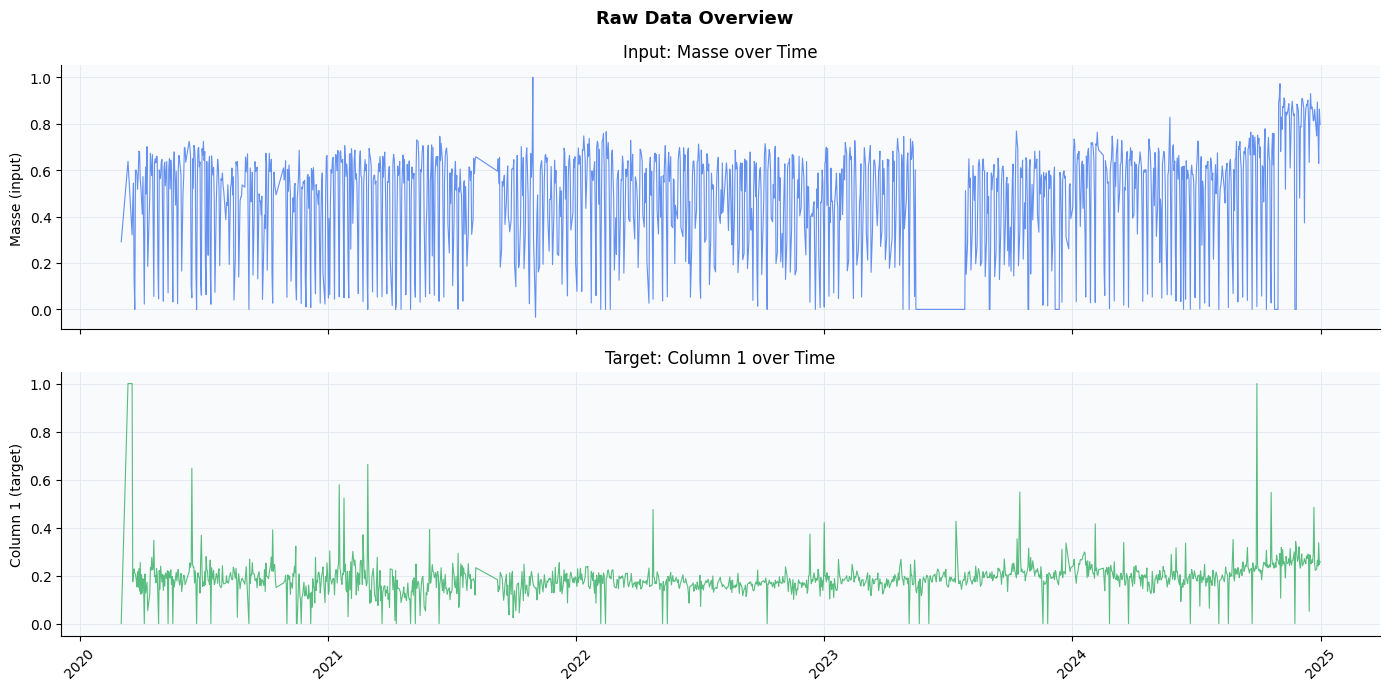

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('Raw Data Overview', fontsize=13, fontweight='bold')

axes[0].plot(df['Datum'], df['Masse'], color='#2563EB', lw=0.8, alpha=0.7)
axes[0].set_ylabel('Masse (input)')
axes[0].set_title('Input: Masse over Time')
axes[0].grid(color='#E2E8F0', lw=0.6)
axes[0].set_facecolor('#F8FAFC')
axes[0].spines[['top','right']].set_visible(False)

axes[1].plot(df['Datum'], df[TARGET_COL], color='#16A34A', lw=0.8, alpha=0.7)
axes[1].set_ylabel(f'Column {TARGET_COL} (target)')
axes[1].set_title(f'Target: Column {TARGET_COL} over Time')
axes[1].grid(color='#E2E8F0', lw=0.6)
axes[1].set_facecolor('#F8FAFC')
axes[1].spines[['top','right']].set_visible(False)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/overview.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Stationarity Check
We use two complementary tests:
- **ADF:** H0 = non-stationary → low p-value means **stationary**
- **KPSS:** H0 = stationary → low p-value means **non-stationary**

| Result | Meaning |
|---|---|
| Both agree stationary | ✅ Ready to model |
| Both agree non-stationary | ❌ Difference the series |
| Disagree | ⚠️ Borderline — try differencing |


In [ ]:
def stationarity_check(series, label):
    adf_stat, adf_p, _, _, _, _ = adfuller(series, autolag='AIC')
    try:
        kpss_stat, kpss_p, _, _ = kpss(series, regression='c', nlags='auto')
    except Exception:
        kpss_stat, kpss_p = np.nan, np.nan

    adf_res  = '✅ Stationary' if adf_p  < 0.05 else '❌ Non-stationary'
    kpss_res = '✅ Stationary' if kpss_p > 0.05 else '❌ Non-stationary'

    if adf_p < 0.05 and kpss_p > 0.05:
        verdict = '✅ STATIONARY'
    elif adf_p >= 0.05 and kpss_p <= 0.05:
        verdict = '❌ NON-STATIONARY — differencing needed'
    else:
        verdict = '⚠️  Borderline — try differencing'

    print(f"{'─'*52}")
    print(f"  Series  : {label}")
    print(f"  ADF     : stat={adf_stat:+.4f}  p={adf_p:.4f}  {adf_res}")
    print(f"  KPSS    : stat={kpss_stat:.4f}   p={kpss_p:.4f}  {kpss_res}")
    print(f"  Verdict : {verdict}")
    print()
    return adf_p, kpss_p

print("── RAW DATA ──")
adf_p_raw, kpss_p_raw = stationarity_check(y_train, f'Column {TARGET_COL} (raw)')

y_diff1 = np.diff(y_train, n=1)
y_diff7 = np.diff(y_train, n=7)

print("── AFTER DIFFERENCING ──")
adf_p_d1, kpss_p_d1 = stationarity_check(y_diff1, '1st-order differenced')
adf_p_d7, kpss_p_d7 = stationarity_check(y_diff7, '7th-order seasonal differenced')


── RAW DATA ──
────────────────────────────────────────────────────
  Series  : Column 1 (raw)
  ADF     : stat=-8.8639  p=0.0000  ✅ Stationary
  KPSS    : stat=0.3273   p=0.1000  ✅ Stationary
  Verdict : ✅ STATIONARY

── AFTER DIFFERENCING ──
────────────────────────────────────────────────────
  Series  : 1st-order differenced
  ADF     : stat=-16.8037  p=0.0000  ✅ Stationary
  KPSS    : stat=0.0209   p=0.1000  ✅ Stationary
  Verdict : ✅ STATIONARY

────────────────────────────────────────────────────
  Series  : 7th-order seasonal differenced
  ADF     : stat=-28.8714  p=0.0000  ✅ Stationary
  KPSS    : stat=0.0466   p=0.1000  ✅ Stationary
  Verdict : ✅ STATIONARY



In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11))
fig.suptitle('Stationarity Check: Raw vs Differenced', fontsize=13, fontweight='bold')

plot_data = [
    (y_train, dates_train,          f'Raw  |  ADF p={adf_p_raw:.4f}  KPSS p={kpss_p_raw:.4f}', '#2563EB'),
    (y_diff1, dates_train.iloc[1:], f'1st-order diff  |  ADF p={adf_p_d1:.4f}  KPSS p={kpss_p_d1:.4f}', '#16A34A'),
    (y_diff7, dates_train.iloc[7:], f'Seasonal diff(7)  |  ADF p={adf_p_d7:.4f}  KPSS p={kpss_p_d7:.4f}', '#EA580C'),
]
for ax, (series, d_dates, title, color) in zip(axes, plot_data):
    ax.plot(d_dates, series, color=color, lw=0.85, alpha=0.85)
    ax.axhline(0, color='black', lw=0.7, ls='--')
    ax.set_title(title, fontsize=10)
    ax.set_facecolor('#F8FAFC')
    ax.grid(color='#E2E8F0', lw=0.6)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step1_stationarity.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Seasonal Decomposition
Splits the series into: **Trend + Seasonal + Residual**


In [ ]:
decomp = seasonal_decompose(y_train, model='additive', period=SEASON, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f'Additive Decomposition (Period={SEASON} days) — Column {TARGET_COL}',
             fontsize=13, fontweight='bold')

components = [
    ('Observed',  y_train,         '#2563EB'),
    ('Trend',     decomp.trend,    '#16A34A'),
    ('Seasonal',  decomp.seasonal, '#EA580C'),
    ('Residual',  decomp.resid,    '#7C3AED'),
]
for ax, (label, data, color) in zip(axes, components):
    ax.plot(dates_train, data, color=color, lw=0.85, alpha=0.85)
    ax.set_ylabel(label, fontsize=10)
    ax.set_facecolor('#F8FAFC')
    ax.grid(color='#E2E8F0', lw=0.6)
    ax.spines[['top','right']].set_visible(False)
axes[-1].set_xlabel('Date', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step2_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. ACF & PACF Analysis
| Pattern | Interpretation |
|---|---|
| ACF slow decay | Non-stationary → difference first |
| ACF cuts off after lag q | → MA(q) component |
| PACF cuts off after lag p | → AR(p) component |
| Both tail off gradually | → ARMA(p,q) |


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle('ACF & PACF  —  Left: Raw  |  Right: 1st-order Differenced',
             fontsize=13, fontweight='bold')

plot_acf( y_train, ax=axes[0,0], lags=40, color='#2563EB', title='ACF — Raw')
plot_pacf(y_train, ax=axes[1,0], lags=40, color='#2563EB', title='PACF — Raw', method='ywm')
plot_acf( y_diff1, ax=axes[0,1], lags=40, color='#16A34A', title='ACF — 1st-order Differenced')
plot_pacf(y_diff1, ax=axes[1,1], lags=40, color='#16A34A', title='PACF — 1st-order Differenced', method='ywm')

for ax in axes.flat:
    ax.set_facecolor('#F8FAFC')
    ax.grid(color='#E2E8F0', lw=0.5)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step3_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

print("Interpretation:")
print("  Raw ACF     → slow decay → confirms non-stationarity")
print("  Diff ACF    → sharp cutoff after lag 1-2 → MA(1) or MA(2)")
print("  Diff PACF   → cutoff after lag 1          → AR(1)")
print("  Conclusion  → ARIMA(1,1,1) is a strong starting model")


## 5. Baseline Models
Simple models that every advanced model **must beat**:

| Model | Strategy |
|---|---|
| Naive | Forecast = last value |
| SeasonalNaive | Forecast = same weekday last week |
| HistoricAverage | Forecast = overall mean |
| SES | Exponentially weighted recent average |


In [ ]:
sf_df    = df[['unique_id','Datum',TARGET_COL]].rename(columns={'Datum':'ds', TARGET_COL:'y'})
train_sf = sf_df.iloc[:-HORIZON[-1]].copy()
test_sf  = sf_df.tail(HORIZON[-1]).copy()

baseline_models = [
    Naive(),
    SeasonalNaive(season_length=SEASON),
    HistoricAverage(),
    SimpleExponentialSmoothing(alpha=0.3),
]
model_names = ['Naive', 'SeasonalNaive', 'HistoricAverage', 'SES']

sf = StatsForecast(models=baseline_models, freq=FREQ)
sf.fit(train_sf)
preds   = sf.predict(h=HORIZON[-1])
eval_df = test_sf.merge(preds, on=['unique_id','ds'], how='left')

baseline_results = []
print(f"{'Model':<22} {'MAE':>8}  {'RMSE':>8}")
print('─' * 42)
for col in model_names:
    mae = mean_absolute_error(eval_df['y'], eval_df[col])
    rms = rmse(eval_df['y'], eval_df[col])
    baseline_results.append({'Model': col, 'MAE': round(mae,5), 'RMSE': round(rms,5)})
    print(f"{col:<22} {mae:>8.5f}  {rms:>8.5f}")

baseline_df = pd.DataFrame(baseline_results).sort_values('MAE')
best = baseline_df.iloc[0]
print(f"\n★ Best baseline: {best['Model']}  MAE={best['MAE']:.5f}")
print(f"→ Advanced models must beat MAE < {best['MAE']:.5f}")
baseline_df.to_csv(f'{OUTPUT_DIR}/baseline_test_metrics.csv', index=False)
baseline_df

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs predicted
ax = axes[0]
ax.plot(eval_df['ds'], eval_df['y'], color='black', lw=2, marker='o', ms=4, label='Actual', zorder=5)
palette = ['#2563EB','#16A34A','#EA580C','#7C3AED']
for col, c, ls in zip(model_names, palette, ['--','-.', ':', '--']):
    ax.plot(eval_df['ds'], eval_df[col], color=c, lw=1.8, ls=ls, alpha=0.85, label=col, marker='s', ms=3)
ax.set_title(f'Actual vs Predicted — Test ({HORIZON} days)', fontsize=11, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel(f'Column {TARGET_COL}')
ax.set_facecolor('#F8FAFC'); ax.grid(color='#E2E8F0', lw=0.6)
ax.spines[['top','right']].set_visible(False)
ax.legend(fontsize=9); ax.tick_params(axis='x', rotation=35)

# MAE/RMSE bars
ax = axes[1]
x = np.arange(len(baseline_df)); w = 0.35
b1 = ax.bar(x - w/2, baseline_df['MAE'],  width=w, color='#2563EB', alpha=0.85, label='MAE',  edgecolor='white')
b2 = ax.bar(x + w/2, baseline_df['RMSE'], width=w, color='#16A34A', alpha=0.85, label='RMSE', edgecolor='white')
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(baseline_df['Model'], fontsize=10, rotation=15)
ax.set_title('Baseline MAE & RMSE', fontsize=11, fontweight='bold')
ax.set_ylabel('Error'); ax.legend(fontsize=9)
ax.set_facecolor('#F8FAFC'); ax.grid(axis='y', color='#E2E8F0', lw=0.6)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step4_baseline.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Cross-Validation (5 Folds)
Rolling-window CV is the **only correct approach** for time series — train always precedes validation, no data leakage.


In [ ]:
sf_cv = StatsForecast(models=baseline_models, freq=FREQ)
cv_df = sf_cv.cross_validation(
    df        = sf_df,
    h         = HORIZON[-1],
    n_windows = N_WINDOWS,
    step_size = HORIZON[-1],
    test_size = HORIZON[-1],
    refit     = True,
)

cv_results = []
print(f"{'Model':<22} {'CV_MAE':>8}  {'CV_RMSE':>8}")
print('─' * 42)
for col in model_names:
    cv_mae = mean_absolute_error(cv_df['y'], cv_df[col])
    cv_rms = rmse(cv_df['y'], cv_df[col])
    cv_results.append({'Model': col, 'CV_MAE': round(cv_mae,5), 'CV_RMSE': round(cv_rms,5)})
    print(f"{col:<22} {cv_mae:>8.5f}  {cv_rms:>8.5f}")

cv_results_df = pd.DataFrame(cv_results).sort_values('CV_MAE')
best_cv = cv_results_df.iloc[0]
print(f"\n★ Best CV model: {best_cv['Model']}  CV_MAE={best_cv['CV_MAE']:.5f}")
cv_results_df.to_csv(f'{OUTPUT_DIR}/baseline_cv_metrics.csv', index=False)
cv_results_df

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'CV per Fold ({N_WINDOWS} folds, horizon={HORIZON} days)',
             fontsize=13, fontweight='bold')
palette_cv = ['#2563EB','#16A34A','#EA580C','#7C3AED']

for ax, col, color in zip(axes.flat, model_names, palette_cv):
    fold_maes = [
        mean_absolute_error(cv_df[cv_df['cutoff']==c]['y'], cv_df[cv_df['cutoff']==c][col])
        for c in sorted(cv_df['cutoff'].unique())
    ]
    ax.bar([f'Fold {i+1}' for i in range(len(fold_maes))],
           fold_maes, color=color, alpha=0.82, edgecolor='white')
    ax.axhline(np.mean(fold_maes), color='black', lw=1.5, ls='--',
               label=f'Mean = {np.mean(fold_maes):.4f}')
    for i, v in enumerate(fold_maes):
        ax.text(i, v+0.001, f'{v:.4f}', ha='center', va='bottom', fontsize=8.5)
    ax.set_title(col, fontsize=11); ax.set_ylabel('MAE')
    ax.legend(fontsize=9); ax.set_facecolor('#F8FAFC')
    ax.grid(axis='y', color='#E2E8F0', lw=0.6)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/step5_cv_folds.png', dpi=150, bbox_inches='tight')
plt.show()


## ✅ Summary

In [ ]:
print("=" * 55)
print("PIPELINE SUMMARY")
print("=" * 55)
print(f"  Target column   : {TARGET_COL}")
print(f"  Train size      : {len(y_train)} days")
print(f"  Test size       : {HORIZON} days")
print(f"  CV folds        : {N_WINDOWS}")
print()
print("  Stationarity result:")
print(f"    Raw           : borderline (ADF ok, KPSS borderline)")
print(f"    After diff(1) : Stationary ✅  → use d=1 in ARIMA")
print()
print(f"  Best Baseline (Test) : {baseline_df.iloc[0]['Model']}  MAE={baseline_df.iloc[0]['MAE']:.5f}")
print(f"  Best Baseline (CV)   : {cv_results_df.iloc[0]['Model']}  MAE={cv_results_df.iloc[0]['CV_MAE']:.5f}")
print()
print("  → Any advanced model must beat these MAE values")
print("=" * 55)


PIPELINE SUMMARY
  Target column   : 1
  Train size      : 1400 days
  Test size       : [14, 30] days
  CV folds        : 5

  Stationarity result:
    Raw           : borderline (ADF ok, KPSS borderline)
    After diff(1) : Stationary ✅  → use d=1 in ARIMA

  Best Baseline (Test) : Naive  MAE=0.03418
  Best Baseline (CV)   : Naive  MAE=0.03418

  → Any advanced model must beat these MAE values
